# **Overview**

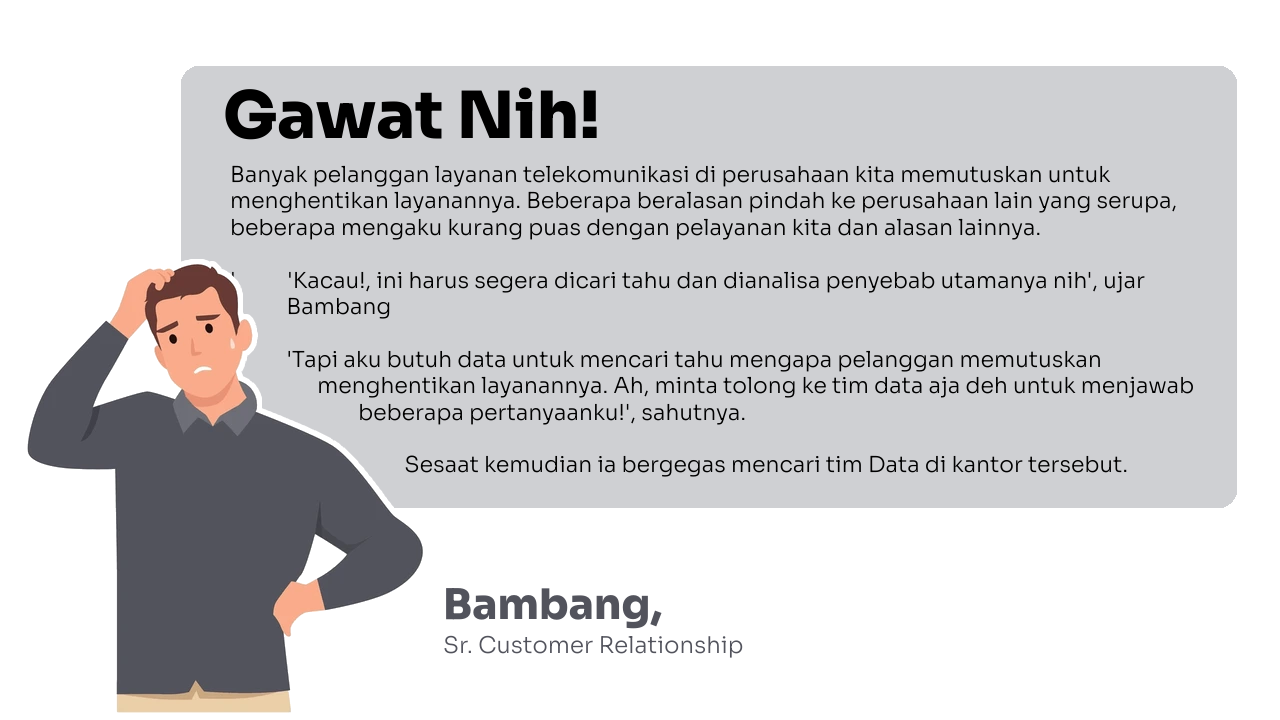

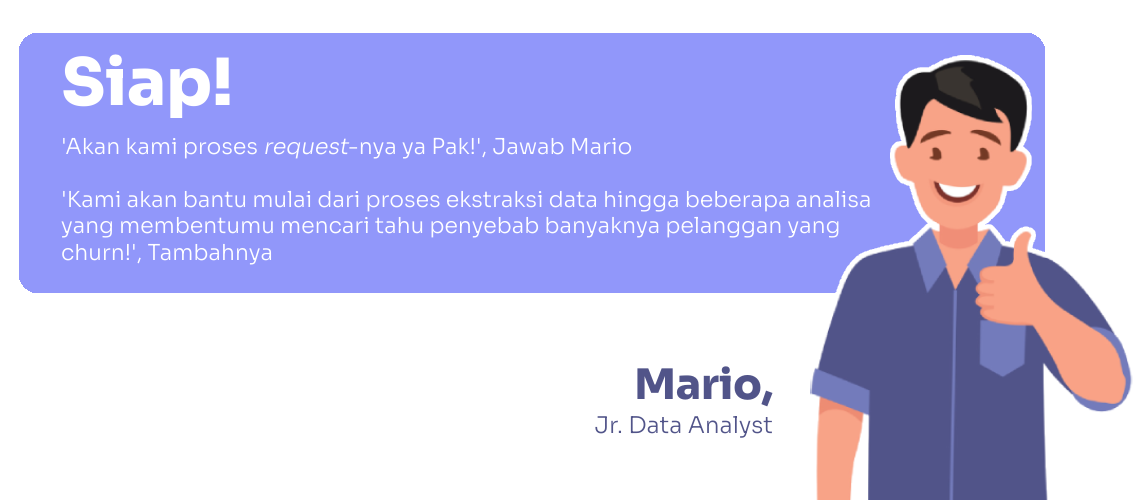

# **A. First Step : Data yang Digunakan**

Data yang digunakan adalah data telco customer yang termuat dalam google big query

In [ ]:
from google.colab import auth, data_table
from google.cloud import bigquery
from pandas_gbq import to_gbq

# Proses autentikasi akun
auth.authenticate_user()
print('Authenticated')

In [ ]:
# Buat BigQuery client
project_id = 'dqlab-project-480212'
client = bigquery.Client(project = project_id)

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

# Inisialisasi query yang akan dijalankan
query = """
  SELECT
    *
  FROM `dqlab-468906.pilotclass.data_telco_customer_clean`
"""

# Proses ekstraksi data dari BigQuery ke pandas
data_telco_clean = client.query(query).to_dataframe()

# Tampilkan hasil
data_telco_clean.head(5)

Berikut deskripsi singkat untuk tiap kolom:

* `customer_id` : ID unik untuk mengidentifikasi setiap pelanggan  
* `open_date` : Tanggal pelanggan pertama kali bergabung atau membuka akun layanan  
* `gender` : Jenis kelamin pelanggan (Male/Female)  
* `age` : Usia pelanggan dalam tahun  
* `married` : Status pernikahan pelanggan (Yes/No)  
* `number_of_dependents` : Jumlah tanggungan yang dimiliki pelanggan  
* `satisfaction_score` : Skor kepuasan pelanggan terhadap layanan (skala 1–5)  
* `customer_status` : Status pelanggan saat ini (Active, Churned, Joined)  
* `cltv` : Customer Lifetime Value, nilai total yang dihasilkan pelanggan sepanjang masa berlangganan  
* `number_of_referrals` : Jumlah referral/rekomendasi yang dilakukan pelanggan  
* `tenure_in_months` : Lama pelanggan berlangganan dalam bulan  
* `offer` : Penawaran khusus atau paket promosi yang diterima pelanggan (misalnya Offer A, Offer B, None)  
* `phone_service` : Status penggunaan layanan telepon (Yes/No)  
* `internet_service` : Status penggunaan layanan internet (Yes/No)  
* `internet_type` : Jenis layanan internet yang digunakan (DSL, Fiber Optic, Cable)  
* `contract` : Jenis kontrak pelanggan (Month-to-Month, One Year, Two Year)  
* `payment_method` : Metode pembayaran yang digunakan pelanggan (Credit Card, Bank Transfer, Electronic Check, dll.)  
* `monthly_charge` : Biaya langganan bulanan pelanggan  
* `total_revenue` : Total pendapatan yang dihasilkan dari pelanggan sejak bergabung  
* `churn_category` : Kategori alasan churn pelanggan
* `churn_date` : Tanggal kapan customer berhenti berlangganan
* `churn_reason` : Alasan spesifik pelanggan berhenti berlangganan  


In [ ]:
# Memperoleh informasi umum pada data
data_telco_clean.info()

In [ ]:
# Konversi tipe data yang sesuai
data_telco_clean['monthly_charge'] = data_telco_clean['monthly_charge'].astype(pd.Float64Dtype())
data_telco_clean['total_revenue'] = data_telco_clean['total_revenue'].astype(pd.Float64Dtype())

data_telco_clean['open_date'] = pd.to_datetime(data_telco_clean['open_date'])
data_telco_clean['churn_date'] = pd.to_datetime(data_telco_clean['churn_date'])

In [ ]:
# Memperoleh informasi setelah di konversi
data_telco_clean.info()

## **Data Profiling**

Data profiling adalah proses menganalisis dan menilai kualitas data secara menyeluruh untuk memahami struktur, isi, dan kualitas dataset sebelum digunakan.

Untuk melakukan data profiling pada pandas dapat menggunakan library `ydata-profiling`


### 👨‍💻 Task 1A - Lakukan installasi library

Install library ydata-profiling dengan mengeksekusi perintah

```pip install ydata-profiling```

In [ ]:
pip install ydata-profiling

### 👨‍💻 Task 1B - Proses Profiling Data

Setelah library terinstall, lakukan proses profiling data pada DataFrame `data_telco_clean` dan beri judul Data Profiling Report

<br>docs: *https://docs.profiling.ydata.ai/latest/getting-started/concepts/*

In [ ]:
# Import library yang digunakan
from ydata_profiling import ProfileReport

# Lakukan proses profiling data
profile = ProfileReport(
    df = data_telco_clean,
    title = 'Data Profiling Report - Telco Churn'
)

# Tampilkan hasilnya
display(profile)

### 👨‍💻 Task 1C - Perlu Disimpan?

Profiling Data bisa disimpan untuk kebutuhan reporting kepada audiens. Simpan hasil profiling ke dalam file dengan nama `data_profiling_report_telco.html`

In [ ]:
# Definsikan nama file
nama_file = 'data_profiling_report_telco.html'

# Simpan hasilnya
profile.to_file(nama_file)

*Setelah membaca hasil profiling datanya, adakah kamu menemukan sesuatu yang menarik?*

In [ ]:
# Lakukan perbaikan disini jika ditemukan
data_telco_clean['gender'] = data_telco_clean['gender'].map({
    'Men' : 'Male',
    'Woman' : 'Female',
    'Male' : 'Male',
    'Female' : 'Female'
})

---
# **B. Prerequisite : Data Visualization**

Visualisasi data adalah proses menyajikan data dalam bentuk visual—seperti grafik, diagram, peta, atau dashboard—agar data lebih mudah dipahami, dianalisis, dan dikomunikasikan dibandingkan hanya melihat angka mentah atau tabel panjang. Tujuan proses visualisasi data :

1. Mempermudah pemahaman
2. Menemukan pola & anomali
3. Mendukung pengambilan keputusan
4. Memudahkan komunikasi data
5. Membandingkan data dengan jelas

<br>**Data Visualization Cheat Sheet**

<img src="https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F1688884%2Fb4372f0e806b6f75c7b56904b1159a68%2FData%20Visualization%20Cheatsheet.jpg?generation=1592767560257939&alt=media" width="60%">

https://public.tableau.com/app/profile/andy.kriebel/viz/VisualVocabulary/VisualVocabulary



## **Teknik Visualisasi Data**

Untuk melakukan visualisasi biasanya akan dilakukan proses agregasi terlebih dahulu baru melakukan visualisasi data. Gunakan library plotly untuk menampilkan visualisasi yang dinamis di Python

```
import plotly.express as px
```

<br>docs : *https://plotly.com/python/*

### 👨‍💻 Task B1 - Agregasi Data

Hitung total customer berdasarkan status customer tersebut yang ada pada data lalu simpan kedalam variabel `total_cust_per_status` dan tampilkan datanya!

In [ ]:
# Buat agregasi terlebih dahulu
total_cust_per_status = data_telco_clean.groupby('customer_status', as_index = False).agg(total_customer = ('customer_id', 'count'))

# Tampilkan data
display(total_cust_per_status)

In [ ]:
# Cara lain / shortcutnya
data_telco_clean['customer_status'].value_counts()

### 👨‍💻 Task B2 - Visualisasi Pertamamu

Setelah agregasi terbentuk, langkah selanjutnya adalah lakukan visualisasi dengan diagram Pie!

<br>docs: *https://plotly.com/python/pie-charts/*

In [ ]:
# Import library untuk visualisasi
import plotly.express as px

# Buat pie chart
fig = px.pie(
    names = total_cust_per_status['customer_status'],
    values = total_cust_per_status['total_customer']
)

# Tampilkan diagram
fig.show()

## **Prinsip GESTALT**

Grafik sudah terbentuk? Keren! Kamu sudah berhasil membuat grafik dinamis di Python (coba arahkan kursor ke grafik tersebut :D). Nah yang lebih menarik, ada aturan atau prinsip 'khusus' agar visualisasimu tampak lebih menarik. Prinsip tersebut biasa dikenal dengan GESTALT Principle.

Prinsip GESTALT dalam visualisasi data adalah sekumpulan prinsip psikologi persepsi yang menjelaskan bagaimana otak manusia secara alami mengelompokkan dan menafsirkan elemen visual. Prinsip ini membantu kita merancang visualisasi yang lebih intuitif, mudah dibaca, dan tidak membingungkan.

<br>***Kenapa Gestalt penting dalam visualisasi data?***

Karena visualisasi yang baik mengikuti cara otak bekerja, bukan memaksa pembaca berpikir keras.

Dengan Gestalt:
* Grafik lebih cepat dipahami
* Pola langsung terlihat
* Risiko salah tafsir berkurang

<img src="https://miro.medium.com/v2/1*cfRl07KmQMIRtk5IZmIWcA.png" width="50%">

<br>docs: *https://www.interaction-design.org/literature/topics/gestalt-principles?srsltid=AfmBOoqICMh7lMbMvuDNVpdP6NL33JI27GygHz5EZt3eBBdETMzSbQBy*

### 👨‍💻 Task B3 - Percantik Visualisasimu

Lengkapi kode berikut untuk membuat visualisasi yang menerapkan prinsip GESTALT

In [ ]:
total_cust_per_status

In [ ]:
# Import library untuk visualisasi
import plotly.express as px

# Hitung total data
total_data = total_cust_per_status['total_customer'].sum()

# Warna
lemon_lime = '#e4ea8c'
basil_green = '#3f6c45'
strawberry = '#cb0000'

# Buat pie chart
fig = px.pie(
    names = total_cust_per_status['customer_status'],
    values = total_cust_per_status['total_customer'],
    color_discrete_sequence = [lemon_lime, strawberry, basil_green],
    hole = 0.65
)

# Atur posisi label
fig.update_traces(
    textposition = 'outside',
    textinfo = 'percent+label',
    hovertemplate='<b>%{label}</b><br>%{value} Customers'
)

# Atur luas grafik, hapus legend dan beri judul
fig.update_layout(
    width = 800,
    height = 600,
    showlegend = False,
    margin = dict(l=160, r=200, t=100, b=30),
    title = dict(
        text = f"<b>Proporsi Status Pelanggan Perusahaan Telco</b><br><sup>Lebih dari seperempat customer telah <span style='color:{strawberry}'><b>berhenti berlangganan</b></span></sup>",
        font = dict(
            size = 22,
            color = '#50312f'
        ),
        y = 0.92,
        x = 0.09
    )
)

# Berikan informasi total pelanggan di tengah donut chart
fig.add_annotation(
    text = f'Total Pelanggan<br><b><span style="font-size: 28px;">{total_data}</b></span>',
    x = 0.5,
    y = 0.5,
    showarrow = False,
    font = dict(size = 20)
)

# Tampilkan grafik
fig.show()

*Bagaimana? Apakah ada perubahan signifikan? Menurutmu kenapa total pelanggan tiap statusnya perlu kita visualisasikan dengan diagram donut dengan kombinasi warna diatas?*

✍🏼 Share your answer!

Dengan menggunakan pie/donat chart bisa memberikan emphasis ke fokus utama, yaitu *customer churn rate*. Insight utama jadi cepat tertangkap, perhatian audiens tidak terdistraksi oleh nilai lain, dan pesan analisisnya tersampaikan lebih jelas serta efektif.
Serta pemilihan chart dan kombinasi warna yang tepat dapat menjadi penentu keberhasilan dalam menyampaikan insights secara efektif dan menarik perhatian audiens.

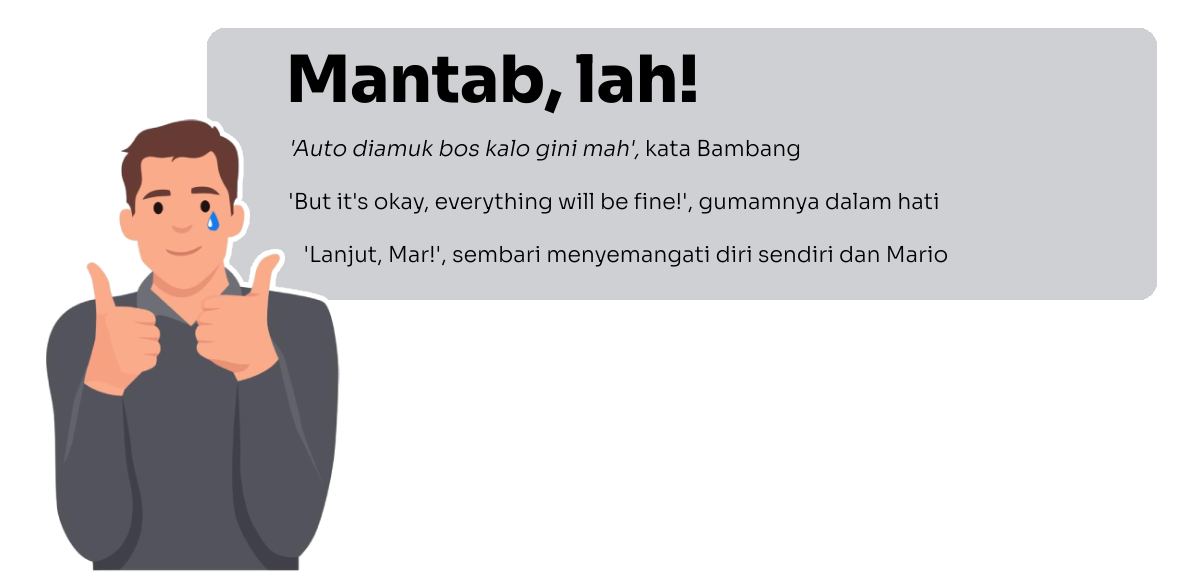

**Anatomy of a Figure**

<img src="https://matplotlib.org/stable/_images/sphx_glr_anatomy_001_2_00x.png">

---

# **C. Identifikasi Masalah Utama**

Identifikasi masalah utama adalah proses menemukan apa sebenarnya masalah inti yang sedang dihadapi sebuah bisnis sebelum melakukan analisis atau mengambil keputusan. Hal ini seperti mencari akar persoalan (root cause), bukan hanya gejalanya.

### 👨‍💻 Task C - Identifikasi Masalah Utama

> *Langkah Awal, dari hasil visualisasi data total customer tiap status. Menurutmu apa masalah yang sedang dihadapi oleh perusahaan Telco tersebut?*


In [ ]:
fig.show()

✍🏼 *Insight :*      

Tingginya customer churn rate (>25%) menunjukkan adanya masalah serius dalam retensi pelanggan. Sebagian besar pelanggan berpindah layanan karena kompetitor memiliki penawaran dan perangkat yang lebih baik.

Oleh karena itu, perusahaan perlu melakukan *competitor analysis*, meningkatkan kualitas layanan, memperkuat program loyalitas, dan paket layanan yang lebih sesuai dengan kebutuhan pelanggan, sehingga pelanggan tetap berlangganan dan tingkat churn dapat ditekan.

# **D. Statistika Deskriptif Univariate**

Statistika deskriptif adalah cabang statistika yang digunakan untuk menggambarkan, merangkum, dan menyajikan data agar mudah dipahami. Tujuannya bukan untuk menarik kesimpulan atau memprediksi sesuatu, tetapi untuk **memahami pola dasar dari data yang sudah ada**. Statistika deskriptif diantaranya adalah menghitung :
<br><br>

**Data Numerik**
1. **Ukuran Pemusatan** (*Measures of Central Tendency*) : Mean, Median dan Modus
2. **Ukuran Penyebaran** (*Measures of Variability*) : Range, Variance, Standard deviation dan
Interquartile range (IQR)
3. **Ukuran Bentuk Distribusi**
<br>

**Data Kategorik**
1. **Frekuensi** Data
2. **Proporsi** Data

### 👨‍💻 Task D1 - List Kolom Numerik & Kolom Kategorik

> *Tampilkan perhitungan statistika deskriptif semua kolom numerik pada DataFrame `data_telco_clean`*

<br>

Untuk menyeleksi kolom numerik atau kategorik saja pada DataFrame dapat menggunakan

```
DataFrame.select_dtypes(include = ['<type>']).columns
```


docs : *https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html*

In [ ]:
# Definisikan kolom numerik
kolom_numerik = data_telco_clean.select_dtypes(include = 'number').columns

# Tampilkan hasilnya
display(kolom_numerik)

In [ ]:
# Definisikan kolom non-numerik
kolom_non_numerik = data_telco_clean.select_dtypes(include = 'object').columns

# Tampilkan hasilnya
display(kolom_non_numerik)

### 👨‍💻 Task D2 - Statistik Deskriptif Kolom Numerik

> *Tampilkan perhitungan statistika deskriptif semua kolom numerik pada DataFrame `data_telco_clean`*

<br>

Untuk menghitung statistik deskriptif pada data numerik dengan cepat gunakan

```
DataFrame.describe(include = ['number'])
```


docs : *https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html*

In [ ]:
# Statistik Deskriptif kolom Numerik
statistik_deskriptif = data_telco_clean.describe(include = ['number']).T

# Tampilkan hasilnya
display(statistik_deskriptif)

*Notes:*

T = Transpose → Mengubah kolom menjadi baris atau sebaliknya

#### **🔎 Task D2 - Insight**

Age : Rataan umur sebanding dengan nilai tengahnya yakni disekitar 46 tahun dengan simpangan baku 16,75 = 17 tahun. Seperempat pelanggan perusahaan telco berusia 32 tahun dan seperempatnya lagi lebih dari 60 tahun

## 👨‍💻 Task D3 - Statistik Deskriptif Kolom Kategorik

> *Tampilkan perhitungan frekuensi semua kolom kategorik pada DataFrame `data_telco_clean`*

<br>

Untuk menghitung statistik deskriptif pada data kategorik gunakan

```
Series.value_counts(dropna = False)
```


docs : *https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html*

In [ ]:
# Statistik Deskriptif kolom Kategorik (non-numerik)
for col in kolom_non_numerik:
    jumlah_unik = data_telco_clean[col].nunique()
    frekuensi = data_telco_clean[col].value_counts(dropna = False).reset_index()

    print(f'> Frekuensi \033[93m{col}\033[0m')
    print(f'  Terdapat {jumlah_unik} data unik\n')
    display(frekuensi)
    print('\n')

#### **🔎 Task D3 - Insight**

Alasan banyaknya pelanggan yang *churn* dikarenakan kompetitor dipercaya memiliki perangkat atau penawaran yang lebih baik.

## 👨‍💻 Task D4 - Distribusi Data

> *Pada DataFrame `data_telco_clean` tampilkan seluruh distribusi data numerik!*

Distribusi data adalah gambaran tentang bagaimana nilai-nilai dalam sebuah dataset tersebar. Dengan kata lain, distribusi data menjelaskan:

* Seberapa sering suatu nilai muncul
* Bagaimana pola penyebaran nilai (merata, menumpuk, miring, dll)
* Bentuk keseluruhan data

<img src="https://upload.wikimedia.org/wikipedia/commons/c/cc/Relationship_between_mean_and_median_under_different_skewness.png" width="60%">

docs : *https://plotly.com/python/histograms/*

In [ ]:
# Your Code
import plotly.express as px

# Definisikan kolom beserta warnanya
color_map = {
  'age' : '#76B7B2',
  'satisfaction_score' : '#E15759',
  'cltv' : '#F28E2B',
  'number_of_referrals' : '#EDC948',
  'tenure_in_months' : '#59A14F',
  'monthly_charge' : '#4E79A7',
  'total_revenue' : '#B07AA1'
}

# Plot histogram masing-masing kolom
for col in color_map.keys():
    fig = px.histogram(
        data_telco_clean[col],
        x = col,
        # nbins = 50,
        color_discrete_sequence = [color_map.get(col)],
        marginal = "box"
        #hover_data = data_telco_clean.columns
    )

    fig.update_yaxes(
        showgrid = False,
        showticklabels=False,
        title =''
    )

    fig.update_layout(
        title={
          'text' : f'Distribusi <b><span style="color:{color_map.get(col)}">{col}</span></b> Pelanggan<b><br><sup><sup>Perusahaan Telekomunikasi</sup></sup>',
            'y':0.92,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'
        },
        plot_bgcolor = 'rgba(0,0,0,0)',
        bargap = 0.01,
        title_font = dict(size = 25)
    )

    fig.show()

#### **🔎 Task D4 - Insight**

Pada grafik distribusi menunjukkan bahwa sebagian besar pelanggan berada pada tingkat kepuasan dan nilai ekonomi menengah, yang mengindikasikan potensi churn jika tidak diikuti strategi retensi yang tepat. Di sisi lain, terdapat kelompok kecil pelanggan dengan CLTV dan total revenue tinggi yang berkontribusi signifikan terhadap pendapatan perusahaan sehingga perlu menjadi prioritas dalam program loyalitas.

## 👨‍💻 Task D5 - Outlier

> *Pada DataFrame `data_telco_clean` identifikasi adanya outlier dengan box plot! Jika ditemukan indikasi outlier lakukan penanganan yang tepat*

Outlier adalah nilai data yang jauh berbeda atau menyimpang secara ekstrem dari sebagian besar data lain dalam sebuah dataset.

<img src="https://ouzhang.me/blog/outlier-series/sidebar-featured.jpg" width="40%">

Kriteria disebut outlier menurut statistika non-parameterik (statistika yang mengabaikan asumsi) adalah sebagai berikut :
<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*0MPDTLn8KoLApoFvI0P2vQ.png" width="60%">

Sebuah nilai x disebut outlier apabila:
\begin{equation}
x < Q_1 - 1.5 \times IQR
\end{equation}
atau
\begin{equation}
x > Q_3 + 1.5 \times IQR
\end{equation}
dengan:
\begin{equation}
IQR = Q_3 - Q_1
\end{equation}

<br>

docs : *https://plotly.com/python/box-plots/*

In [ ]:
import plotly.express as px

def box_plot(series, column_name, color):
    # Buat horizontal box plot
    fig = px.box(
        series,
        orientation = 'h',
        color_discrete_sequence  = [color]
    )

    # Update layout and display the plot
    fig.update_layout(
        title = f'<b>Box Plot {column_name}</b>',
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        xaxis = dict(
            title = column_name,
            showgrid = False,
            showline = True,
            showticklabels = True,
            zeroline = False,
        )
    )

    fig.show()

In [ ]:
# Lakukan mapping kolom beserta warna
color_map = {
  'age' : '#76B7B2',
  'satisfaction_score' : '#E15759',
  'cltv' : '#F28E2B',
  'number_of_referrals' : '#EDC948',
  'tenure_in_months' : '#59A14F',
  'monthly_charge' : '#4E79A7',
  'total_revenue' : '#B07AA1'
}

# Terapkan ke semua kolom
for column, color in color_map.items():
    box_plot(data_telco_clean[column], column, color)

### Teknik Mengatasi Outlier : Winsorizing
**Winsorizing** adalah teknik untuk mengurangi efek outlier dengan mengganti nilai ekstrem ke nilai batas tertentu alih-alih menghapusnya.



In [ ]:
# Fungsi untuk teknik winsorizing
def teknik_winsorizing(series):
    # Hitung Q1, Q3, dan IQR
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    # Hitung lower dan upper bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Winsorizing: clip nilai ke BATAS bawah & atas
    series = series.astype(pd.Float64Dtype())
    winsorized_series = series.clip(lower=lower_bound, upper=upper_bound)

    return (winsorized_series)

In [ ]:
# Lakukan mapping kolom beserta warna
color_map = {
  'age' : '#76B7B2',
  'satisfaction_score' : '#E15759',
  'cltv' : '#F28E2B',
  'number_of_referrals' : '#EDC948',
  'tenure_in_months' : '#59A14F',
  'monthly_charge' : '#4E79A7',
  'total_revenue' : '#B07AA1'
}

# Terapkan ke semua kolom
for column, color in color_map.items():
      data_telco_clean[column] = teknik_winsorizing(data_telco_clean[column])

      # Tampilkan boxplotnya
      box_plot(data_telco_clean[column], column, color)

#### **🔎 Task D5 - Insight**

Setelah diterapkan teknik *winsorizing*, data yang sebelumnya teridentifikasi sebagai outlier (nilai-nilai ekstrem pada data) tidak dihapus, melainkan dikoreksi dengan cara **dibatasi pada nilai persentil tertentu (upper dan lower bound)** agar nilainya berada dalam rentang yang wajar. Sehingga distribusi data menjadi lebih stabil dan pengaruh nilai ekstrem terhadap analisis dapat diminimalkan.

# **E. Statistik Deskriptif Multivariate**



##**Korelasi**
Korelasi adalah ukuran statistik yang menunjukkan seberapa kuat dan seberapa arah hubungan antara dua variabel.
<img src="https://www.simplypsychology.org/wp-content/uploads/correlation.jpg" width="40%">

Koefisien korelasi dirumuskan sebagai
\begin{equation}
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
\end{equation}
<br>
Dengan kriteria <br>
<img src="https://i0.wp.com/itfeature.com/wp-content/uploads/2024/05/Coefficient-of-Correlation-range.jpg" width="40%">

### 👨‍💻 Task E1 - Korelasi

> *Pada DataFrame `data_clean_telco` coba hitung dan visualisasikan korelasi antar variabelnya*

In [ ]:
# Task D1 - Hitung korelasi
data_corr = data_telco_clean[kolom_numerik].corr()

# Tampilkan hasilnya
display(data_corr)

In [ ]:
import plotly.express as px

# Buat Grafiknya
fig = px.imshow(
    data_corr,
    color_continuous_scale='darkmint',
    title = '<b>Korelasi Kolom Numerik Dataset Telco<b>',
    text_auto = True
)

#Menyembunyikan skala/rentang korelasi
fig.update_coloraxes(showscale=False)

#Atur judul heatmap
fig.update_layout(
    title = dict(
        x=0.5,
        y=0.9,
        xanchor='center',
        yanchor='top'
    ),
    width=1000,   # lebar figure (px)
    height=800
)

#Menampilkan heatmap
fig.show()

## **Lebih Jauh, Breakdown!**




## 👨‍💻 Task E2 - Breakdown

> *Tampilkan sebaran kolom numerik pada DataFrame `data_telco_clean` berdasarkan masing - masing kategori (Stayed dan Churned)*

Note : Gunakan referensi berikut :
https://plotly.com/python/distplot/ atau https://plotly.github.io/plotly.py-docs/generated/plotly.figure_factory.create_distplot.html

In [ ]:
# Import library yang dibutuhkan
import plotly.figure_factory as ff

def distribution_plot(data_cat_1, data_cat_2, label, column_name):
    # Group data together
    data_cat_1 = data_cat_1[column_name]
    data_cat_2 = data_cat_2[column_name]
    hist_data = [data_cat_1, data_cat_2]
    group_labels = label

    # Create distplot with custom bin_size
    fig = ff.create_distplot(
        hist_data,
        group_labels,
        show_hist = False,
        show_rug = False
    )

    fig.update_layout(
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = f"<b>Distribusi {column_name} Pelanggan</b><br><sup><sup>Berdasarkan Status Pelanggan</sup></sup>",
            font = dict(
                size = 28,
                color = 'black'
            ),
            y = 0.92,
            x = 0.5
        )
    )

    fig.update_xaxes(showline=True, linewidth=1, linecolor='black')
    fig.update_yaxes(showline=True, linewidth=1, linecolor='black')

    # Tampilkan visualisasi
    fig.show()

In [ ]:
# Bagi data ke dalam kelompok
non_churn_cust = data_telco_clean[data_telco_clean['customer_status'] != 'Churned']
churn_cust = data_telco_clean[data_telco_clean['customer_status'] == 'Churned']
label_grup =  ['Stayed', 'Churned']

# Panggil fungsi
for col in ['tenure_in_months', 'cltv', 'monthly_charge', 'total_revenue']:
    distribution_plot(
        data_cat_1 = non_churn_cust,
        data_cat_2 = churn_cust,
        label = label_grup,
        column_name = col
    )

#### **🔎 Task E2 - Insight**

Banyak pelanggan dengan masa berlangganan singkat (kurang dari 10 bulan) yang sudah melakukan *churn*, yang mengindikasikan bahwa perusahaan belum optimal dalam mempertahankan pelanggan pada fase awal berlangganan (*early churn*).

Selain itu, pelanggan yang *churn* memiliki rata-rata *monthly charge* yang lebih tinggi (sekitar $80) dibandingkan pelanggan yang tetap berlangganan. Hal ini mengindikasikan adanya ketidaksesuaian antara harga yang dibayarkan dengan kualitas layanan yang dirasakan pelanggan.

## 👨‍💻 Task E3 - Menyelam Lebih Dalam!

> *Dari DataFrame `data_telco_clean` dengan status customer = Churned tampilkan proporsi masing - masing kolom kategoriknya dalam visualisasi data! Adakah hal menarik yang ditemukan? Share your answer!*


In [ ]:
# Filter data churn saja
data_telco_churn = data_telco_clean[data_telco_clean['customer_status'] == 'Churned']

# Definisikan kolom perhitungan
column_name = [
   'phone_service',
   'internet_service',
   'internet_type',
   'contract',
   'payment_method'
]

# Dataframe kosong sebagai penampung
data_agg = pd.DataFrame()

# Proses agregasi
for i in range(len(column_name)):
    agg = data_telco_churn.groupby(column_name[i], as_index = False).agg(total = ('customer_id', 'count'))
    agg = agg.rename(columns = {column_name[i] : 'type'})
    agg.insert(0, 'column', column_name[i])
    agg['percentage'] = round(agg['total'] / agg.groupby('column')['total'].transform('sum') * 100, 2)
    agg['percentage'] = agg['percentage'].astype(str) + '%'

    if(i == 0):
      data_agg = agg
    else:
      data_agg = pd.concat([data_agg, agg])

In [ ]:
# Urutkan data
data_agg = data_agg.sort_values(by = ['column', 'total'], ascending = [True, False], ignore_index = True)

# Tampilkan
display(data_agg)

In [ ]:
# Atur lebih dahulu datanya
max_values = data_agg.groupby('column')['total'].transform('max')
data_agg['max_flag'] = (data_agg['total'] == max_values)

# Filter hanya data dengan nilai paling tinggi per masing-masing kategori
data_agg = data_agg[data_agg['max_flag'] == True]\
    .sort_values(by = 'total', ascending = True, ignore_index = True)

# Tampilkan hasilnya
display(data_agg)

In [ ]:
import plotly.express as px

# Buat bar horizontal
fig = px.bar(
    data_agg,
    x = 'total',
    y = 'column',
    orientation = 'h',
    text = 'type',
    color_discrete_sequence = ['#f5273f'],
)

# Update warna anotasi menjadi putih
fig.update_traces(
    textfont_color = 'white'
)

# Proses update layout
fig.update_layout(
    width = 1200,
    height = 600,
    plot_bgcolor = 'rgba(0, 0, 0, 0)',
    showlegend = False,
    title = dict(
        text = '<b>Profile Pelanggan Churn</b>',
        font = dict(
            size = 30,
            color = 'black'
        ),
        x = 0.03
    ),
    xaxis = dict(
        title = ''
    ),
    yaxis = dict(
        title = ''
    ),
    margin = dict(
        t = 100,
        l = 100,
        b = 100,
        r = 100
    )
)

annotations = []
for i in range(len(data_agg)):
    annotations.append(
        dict(
            x = data_agg['total'][i],
            y = data_agg['column'][i],
            text = f"{data_agg['percentage'][i]}",
            showarrow = False,
            font = dict(
                color='#F9B5D0'
            ),
            xanchor = 'left',
            xshift = 2
        )
    )

# Tambahkan anotasi
fig.update_layout(annotations=annotations)

# Tampilkan grafik
fig.show()

# **F. Kesimpulan**

Berdasarkan analisis lebih lanjut terhadap profil pelanggan yang churn, ditemukan bahwa faktor dominan berasal dari aspek product development dan layanan. Sebanyak 94% pelanggan churn menggunakan layanan internet service, 91% menggunakan phone service, dan 88% memiliki kontrak tipe month-to-month. Sementara itu, faktor lain seperti metode pembayaran dan tipe internet berkontribusi dalam proporsi yang lebih kecil.

Rekomendasi/Tindak Lanjut :

Perusahaan perlu melakukan evaluasi lebih mendalam terhadap kualitas layanan, khususnya pada:
1. Kinerja layanan internet (kecepatan dan stabilitas jaringan)

2. Cakupan jaringan di berbagai wilayah

3. Kualitas layanan pelanggan (*customer service*), terutama dalam menangani keluhan pelanggan baru.

Fokus perbaikan pada aspek-aspek tersebut diharapkan dapat menurunkan tingkat *early churn* dan meningkatkan retensi pelanggan jangka panjang.


<br>
<a href="https://www.linkedin.com/in/fitri-farha/"><img src="https://img.shields.io/badge/-© 2026 Farha Fitri-0a66c2?style=for-the-badge&logoColor=white"/></a>

<a href="https://dqlab.id/"><img src="https://dqlab.id/files/dqlab/cache/87e30118ebba5ec7d96f6ea8c9dcc10b_x_118_X_55.png" align="left" /></a>